### Introduction to CID for Binary Classification Problems

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
import dice_ml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import CID_numerical
from tqdm import tqdm

### Training the model

It is very important to manage datasets correctly. DiCE requires the dataset containing the target variable in order to be initialised. Conversely, when we carry out training, this variable must be removed. Furthermore, it is advisable that the instances we use for training do not contain the target variable and that the feature names do not include it. 

In [2]:
df = pd.read_csv('Dataset/diabetes.csv')
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Separate into data and outcome 

train_dataset, test_dataset, y_train, y_test = train_test_split(df, df['Outcome'], test_size=0.8, random_state=42)
model = DecisionTreeClassifier()

x_train = train_dataset.drop('Outcome', axis=1)
x_test = test_dataset.drop('Outcome', axis=1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.6715447154471544


> [!WARNING] 
> Dice needs the training dataset with the outcome name

In [16]:
importlib.reload(CID_numerical)

<module 'CID_numerical' from 'c:\\Users\\econti\\Desktop\\CID\\CID_numerical.py'>

### CID Explanation

In [ ]:
from Initializer import DICE
from Dissimilarity_Measure import _ecdf

dice = DICE(model=model,
            training_data=train_dataset,
            features_names=x_train.columns.tolist(),
            target_ft_name='Outcome',
            cf_generation_dice="random")

CID_explainer = CID_numerical.CIDNumericalExplainer(training_data=train_dataset,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='Outcome',
                                                    model=model,
                                                    cf_function=dice,
                                                    distr_approx=_ecdf # we use this because we have low variability
                                                    )

In [14]:
instance = x_train[0:1] # <- a pd dataframe

feature_importances = CID_explainer.explain_instance(instance)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


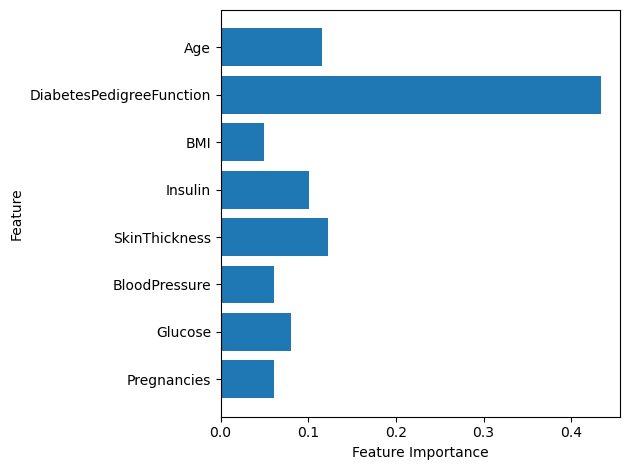

In [17]:
CID_explainer.visualize_feature_importances(feature_importances)

### KNeighbors Explanation

In [ ]:
from Initializer import KNeighbors

Knn = KNeighbors(model=model,
                        training_data=train_dataset,
                        features_names=x_train.columns.tolist()
                        )


CID_explainer = CID_numerical.CIDNumericalExplainer(training_data=train_dataset,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='Outcome',
                                                    model=model,
                                                    cf_function=Knn,
                                                )

instance = x_train[1:2] # 
feature_importances = CID_explainer.explain_instance(instance)


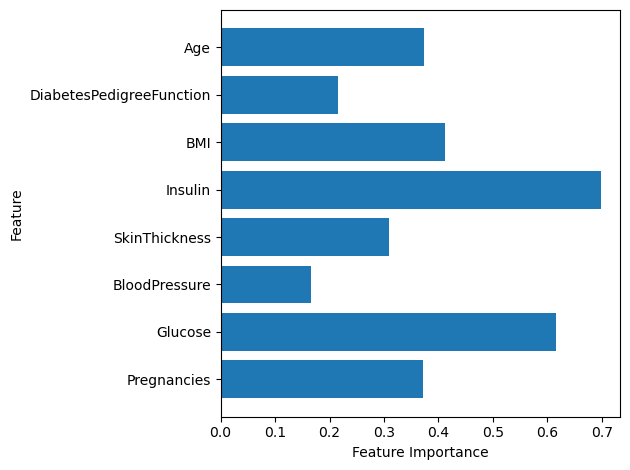

In [7]:
CID_explainer.visualize_feature_importances(feature_importances)

### Random Explanation

In [ ]:
from Initializer import RANDOM

Rand = RANDOM(model=model,
              training_data=train_dataset,
              features_names=x_train.columns.tolist())

CID_explainer = CID_numerical.CIDNumericalExplainer(training_data=train_dataset,
                                                    features_names=x_train.columns.tolist(),
                                                    target_ft_name='Outcome',
                                                    model=model,
                                                    cf_function=Rand,
                                                )

instance = x_train[2:3]
feature_importances = CID_explainer.explain_instance(instance)

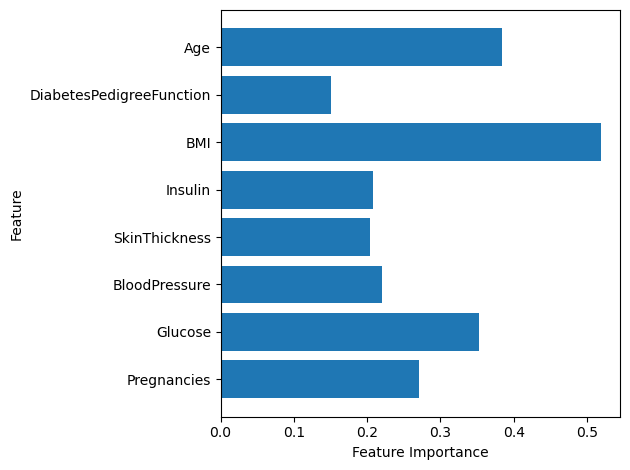

In [11]:
CID_explainer.visualize_feature_importances(feature_importances)